In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
data222=nc.Dataset('/home/dell/iHESPdata/B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1929-06-01.nc')
#data222=nc.Dataset('/home/iHESPdata/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0495-12.nc')
plotvarKMT = data222.variables['KMT'][:,:]
plotvarHT = data222.variables['HT'][:,:]
plotvarHT[plotvarHT==-1] = np.nan
plotvarHT = plotvarHT/100
data=nc.Dataset('/media/dell/Elements/new/SDENFsigma1/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0375-06.SDEN_F.nc')
lontu = data.variables['TLONG'][:,:]
lattu = data.variables['TLAT'][:,:]
lont = data.variables['TLONG'][:,:]
latt = data.variables['TLAT'][:,:]
data2=nc.Dataset('/home/dell/iHESPdata/iHESPocn/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0300-01.nc')
#data2=nc.Dataset('/home/iHESPdata/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0495-12.nc')
plotvar2 = data2.variables['z_w_bot'][:]
lontu[lontu ==-1] = np.nan
lattu[lattu ==-1] = np.nan


In [3]:
data=nc.Dataset('/home/dell/iHESPdata/iHESPocn/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0300-01.nc')
#data=nc.Dataset('/home/iHESPdata/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0495-12.nc')
lont = data.variables['TLONG'][:320,:]
latt = data.variables['TLAT'][:320,:]
#lont[lont==-1]=np.nan
#latt[latt==-1]=np.nan
z = data.variables['z_t'][:]/100
lont2 = data.variables['TLONG'][:420,:]
latt2 = data.variables['TLAT'][:420,:]
lont2[lont2==-1]=np.nan
latt2[latt2==-1]=np.nan
#UVEL = data.variables['UVEL'][0,0,:320,:]
#VVEL = data.variables['VVEL'][0,0,:320,:]

In [4]:
UVELice = np.load('/media/dell/Elements/new/seperatesigma1copy/uvelyesSEP.npy')
VVELice = np.load('/media/dell/Elements/new/seperatesigma1copy/vvelyesSEP.npy')
UVELnoice = np.load('/media/dell/Elements/new/seperatesigma1copy/uvelnoSEP.npy')
VVELnoice = np.load('/media/dell/Elements/new/seperatesigma1copy/vvelnoSEP.npy')
UVELdiffice = UVELice-UVELnoice
VVELdiffice = VVELice-VVELnoice

In [5]:
UVEL = np.load('/media/dell/Elements/new/seperatesigma1copy/UVELyes.npy')
VVEL = np.load('/media/dell/Elements/new/seperatesigma1copy/VVELyes.npy')

In [6]:
pwd

'/home/dell/iHESPplot/Paper3'

In [7]:
PSLyesPP = np.load('/media/dell/Elements/new/seperatesigma1copy/PSLyes.npy')
PSLnoPP = np.load('/media/dell/Elements/new/seperatesigma1copy/PSL000no.npy')
pppPP = PSLyesPP-PSLnoPP

data=nc.Dataset('/media/dell/Elements/new/seperatesigma1copy/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.PSL.h.0375-07.nc')

lontPP = data.variables['lon'][:]
lattPP = data.variables['lat'][:384]
[xx2, yy2] = np.meshgrid(lontPP, lattPP)

In [8]:
VVEL.shape

(320, 3600)

In [9]:
speed = np.sqrt(UVEL*UVEL + VVEL*VVEL)

In [10]:
UVELno = np.load('/media/dell/Elements/new/seperatesigma1copy/UVELno.npy')
VVELno = np.load('/media/dell/Elements/new/seperatesigma1copy/VVELno.npy')

In [11]:
UVELno.shape

(320, 3600)

In [12]:
speedno = np.sqrt(UVELno*UVELno + VVELno*VVELno)

In [13]:
UVELdiff = UVEL-UVELno
VVELdiff = VVEL-VVELno
speeddiff = np.sqrt(UVELdiff*UVELdiff + VVELdiff*VVELdiff)

In [14]:
PSLno = np.load('/home/dell/iHESPplot/windplots/TAUY000noSEP.npy')
PSLyes = np.load('/home/dell/iHESPplot/windplots/TAUYyesSEP.npy')

PSLnoXX = np.load('/home/dell/iHESPplot/windplots/TAUX000noSEP.npy')
PSLyesXX = np.load('/home/dell/iHESPplot/windplots/TAUXyesSEP.npy')

In [15]:
ppp = PSLyes-PSLno
pppXX = PSLyesXX-PSLnoXX

In [16]:
saltyes = np.load('/home/dell/iHESPdata/UVEL/SALTyes.npy')
saltno = np.load('/home/dell/iHESPdata/UVEL/SALTno.npy')
saltdiff = saltyes - saltno
saltdiff[saltdiff==0]=np.nan

In [17]:
SEPno = np.load('/media/dell/Elements/new/seaHi/HInoSEP.npy')
SEPyes = np.load('/media/dell/Elements/new/seaHi/HIyesSEP.npy')
SEPdiff = SEPyes - SEPno

/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:171: UserWarning: The following kwargs were not used by contour: 'spacing'
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:218: UserWarning: The following kwargs were not used by contour: 'spacing'
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:264: UserWarning: The following kwargs were not used by contour: 'spacing'
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:347: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:411: FutureWarning: Using a non-tuple sequence for multidi

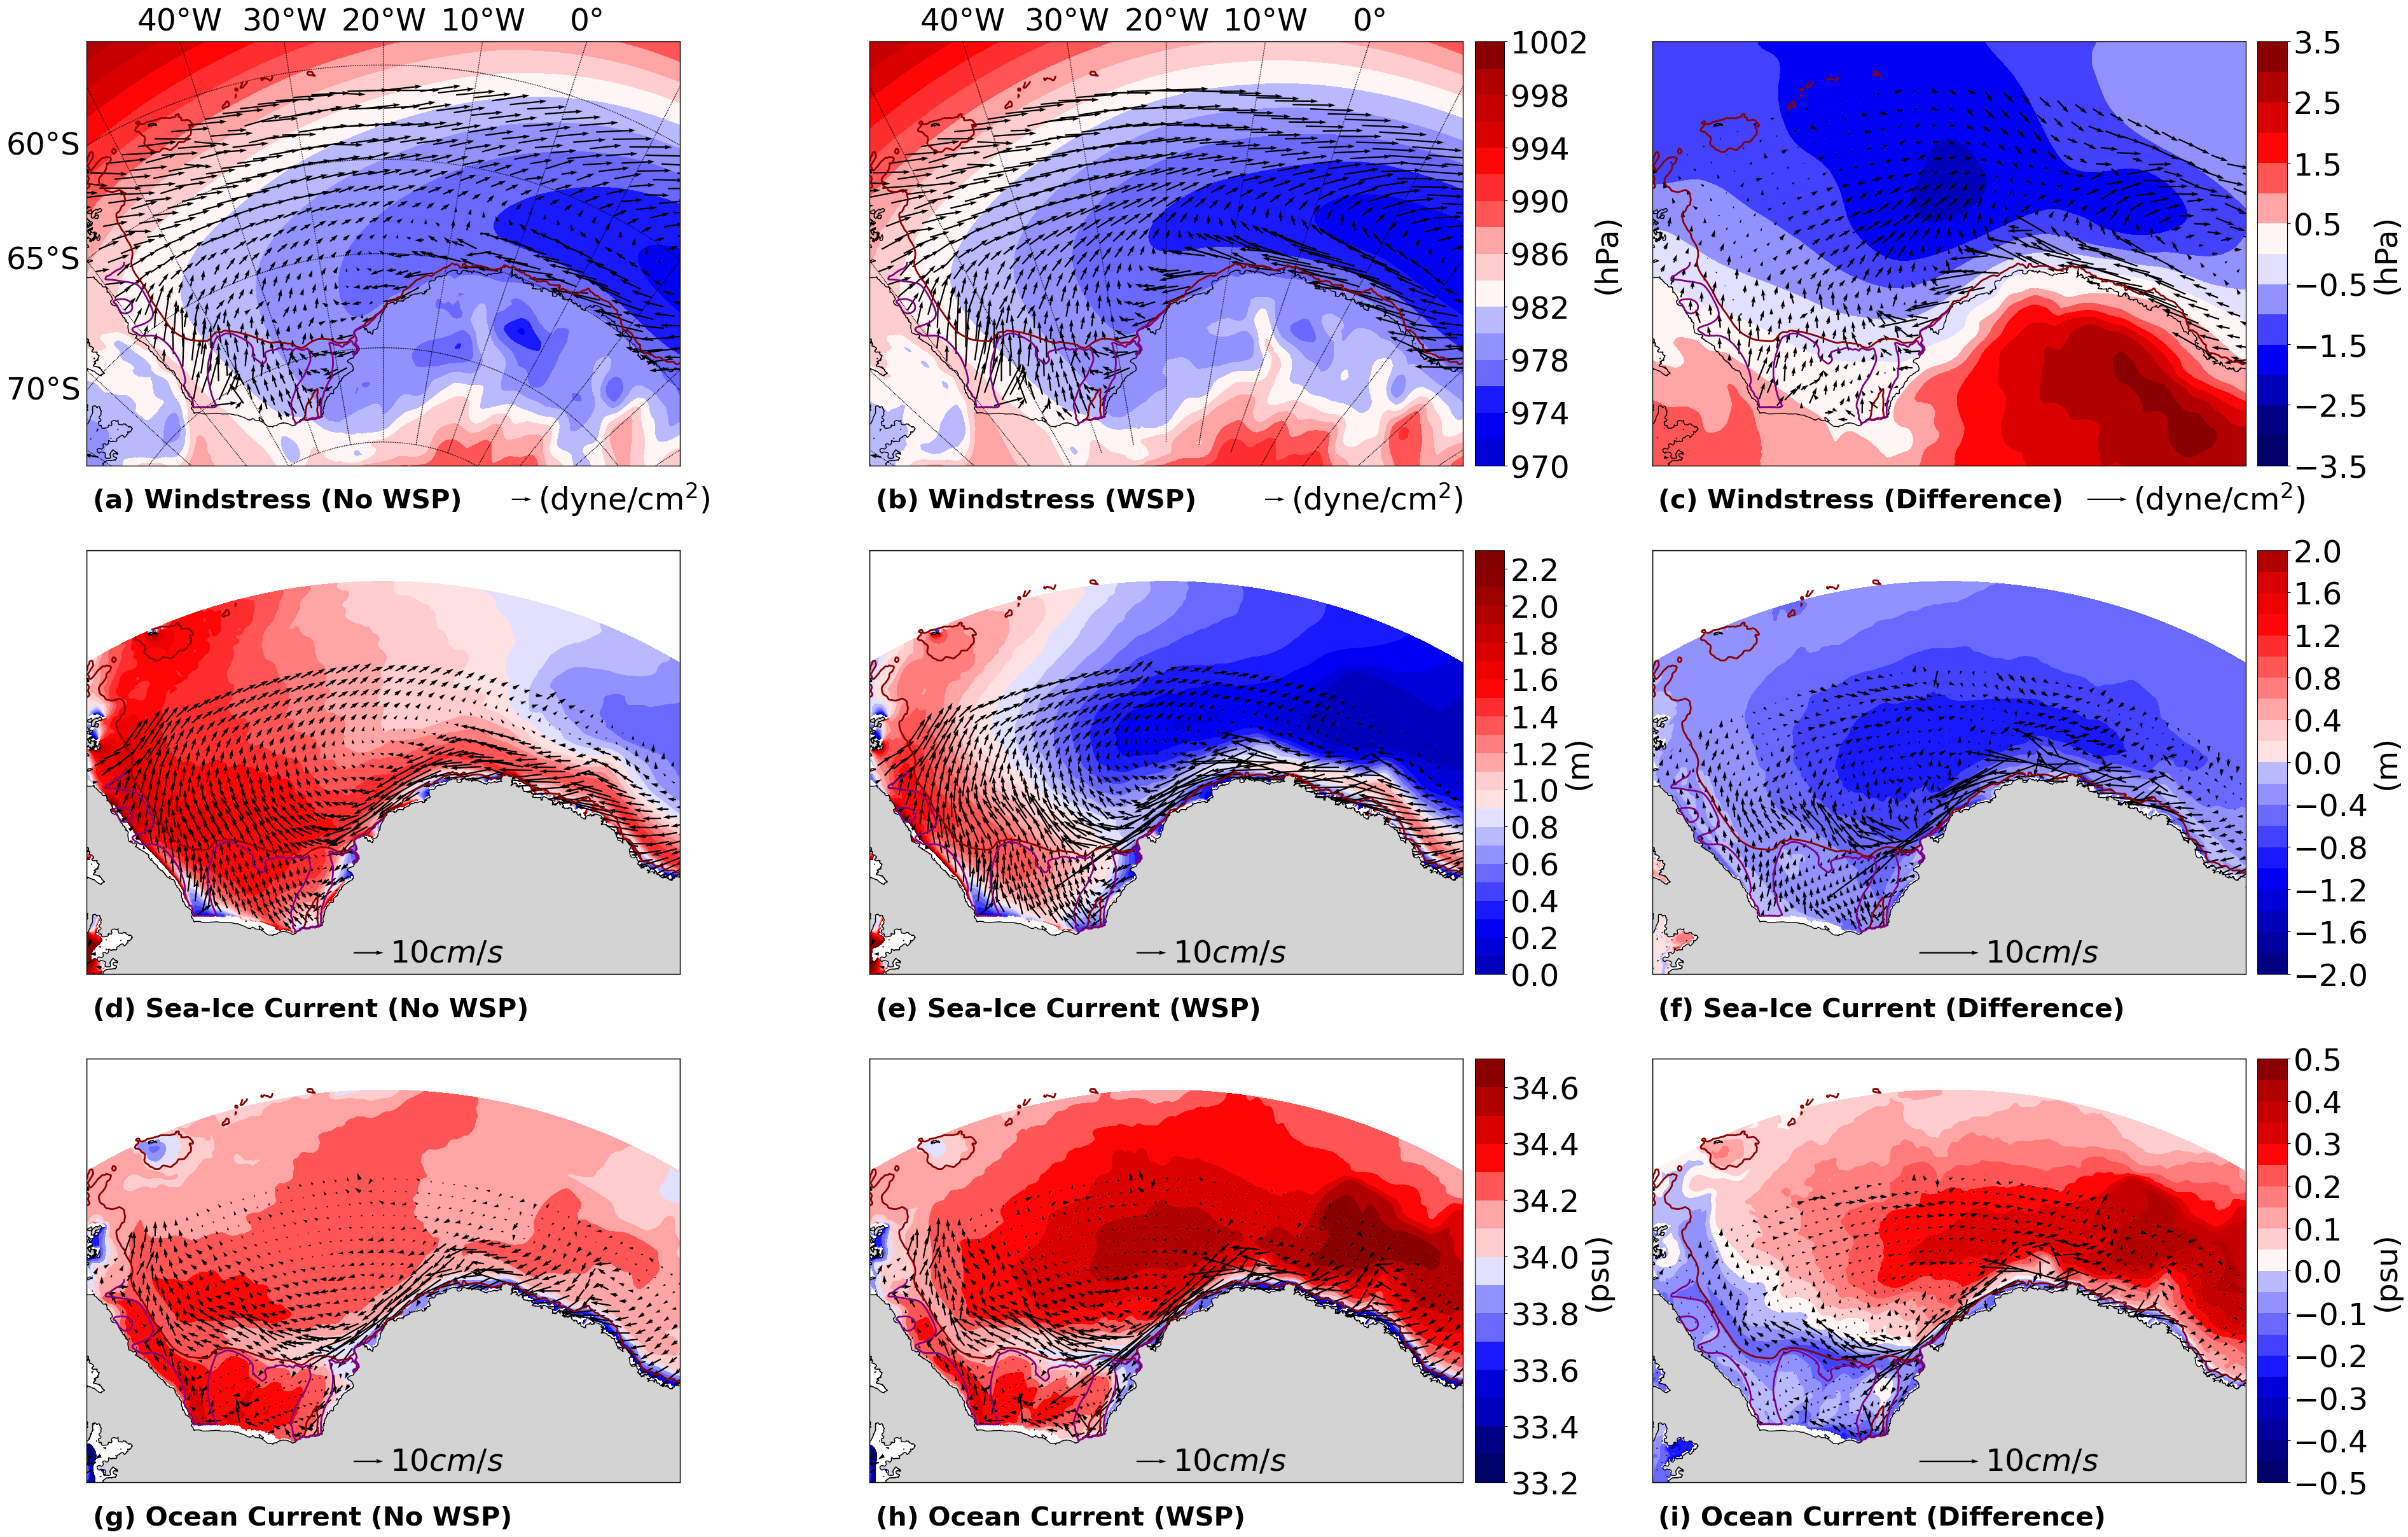

In [18]:

fig = plt.figure(figsize=(45,30), dpi=100)
#ax0 = fig.add_axes([0.1, 0.1, 0.8, 0.36],
                    #xticklabels=[])

ax1 = plt.subplot(3, 3, 7)
my_font = { 'size':'35'}
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,133,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [33.2,33.3,33.4,33.5,33.6,33.7,33.8,33.9,34,34.1,34.2,34.3,34.4,34.5,34.6,34.7]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x[:420,:],y[:420,:],saltno[:420,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(psu)', **my_font)
cbar.remove()
x,y=map(lont,latt)
interval=15
xx=x[::interval,::interval]
yy=y[::interval,::interval]
UVELno1=UVELno[::interval,::interval]
VVELno1=VVELno[::interval,::interval]

CP = map.quiver(xx,yy,UVELno1,VVELno1,scale_units='width',scale=300,color='black')

xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
#ax1.text(0.1, 0.2, 'Ocean Current', transform=ax1.transAxes,size=20,color='black', weight='bold')
ax1.text(0.01, -0.1, '(g) Ocean Current (No WSP) ', transform=ax1.transAxes,size=30,color='black',weight='bold')
ax1.quiverkey(CP, X=0.5, Y=0.05, U=15, fontproperties = my_font,
             label=r'$10  cm/s$', labelpos='E')


ax1 = plt.subplot(3, 3, 8)
my_font = { 'size':'35'}
# set the mapping range
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,133,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [33.2,33.3,33.4,33.5,33.6,33.7,33.8,33.9,34,34.1,34.2,34.3,34.4,34.5,34.6,34.7]
nice_levels2 = [33.2,33.4,33.6,33.8,34,34.2,34.4,34.6]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x[:420,:],y[:420,:],saltyes[:420,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels2)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(psu)', **my_font)

x,y=map(lont,latt)
interval=15
xx=x[::interval,::interval]
yy=y[::interval,::interval]
UVEL1=UVEL[::interval,::interval]
VVEL1=VVEL[::interval,::interval]


CP = map.quiver(xx,yy,UVEL1,VVEL1,scale_units='width',scale=300,color='black')

xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
ax1.text(0.01, -0.1, '(h) Ocean Current (WSP)', transform=ax1.transAxes,size=30, color='black',weight='bold')
ax1.quiverkey(CP, X=0.5, Y=0.05, U=15, fontproperties = my_font,
             label=r'$10  cm/s$', labelpos='E')

ax1 = plt.subplot(3, 3, 9)
my_font = { 'size':'35'}
# set the mapping range
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,133,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-0.5,-0.45,-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]
nice_levels2 = [-0.5,-0.4,-0.3,-0.2,-0.1,0,0.1,0.2,0.3,0.4,0.5]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x[:420,:],y[:420,:],saltdiff[:420,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels2)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(psu)', **my_font)

x,y=map(lont,latt)

interval=15

xx=x[::interval,::interval]
yy=y[::interval,::interval]
UVELd=UVELdiff[::interval,::interval]
VVELd=VVELdiff[::interval,::interval]

CP = map.quiver(xx,yy,UVELd,VVELd,scale_units='width',scale=150,color='black')

xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
ax1.text(0.01, -0.1, '(i) Ocean Current (Difference)', transform=ax1.transAxes,size=30, color='black',weight='bold')
ax1.quiverkey(CP, X=0.55, Y=0.05, U=15, fontproperties = my_font,
             label=r'$10  cm/s$', labelpos='E')

ax1 = plt.subplot(3, 3, 4)

nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230,240,250,260])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2,2.1,2.2,2.3]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x[:420,:],y[:420,:],SEPno[:420,:],levels = nice_levels,cmap = new_cmap,norm =norm,spacing = 'uniform')#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(m)', **my_font)
cbar.remove()

x,y=map(lont,latt)
interval=15
xx=x[::interval,::interval]
yy=y[::interval,::interval]
UVELno1ice=UVELnoice[::interval,::interval]
VVELno1ice=VVELnoice[::interval,::interval]

CP = map.quiver(xx,yy,UVELno1ice,VVELno1ice,scale_units='width',scale=300,color='black')

xq,yq=map(lontu,lattu)
CS = map.contour(xq[:420,:],yq[:420,:],plotvarHT[:420,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
#ax1.text(0.1, 0.2, 'Sea Ice Current', transform=ax1.transAxes,size=20, weight='bold')
ax1.text(0.01, -0.1, '(d) Sea-Ice Current (No WSP)', transform=ax1.transAxes,size=30, weight='bold')
ax1.quiverkey(CP, X=0.5, Y=0.05, U=15, fontproperties = my_font,
             label=r'$10  cm/s$', labelpos='E')


ax1 = plt.subplot(3, 3, 5)

nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230,240,250,260])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2,2.1,2.2,2.3]
nice_levels2 = [0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2,2.2]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x[:420,:],y[:420,:],SEPyes[:420,:],levels = nice_levels,cmap = new_cmap,norm =norm,spacing = 'uniform')#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels2)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(m)', **my_font)

x,y=map(lont,latt)
interval=15
xx=x[::interval,::interval]
yy=y[::interval,::interval]
UVEL1ice=UVELice[::interval,::interval]
VVEL1ice=VVELice[::interval,::interval]


CP = map.quiver(xx,yy,UVEL1ice,VVEL1ice,scale_units='width',scale=300,color='black')

xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
ax1.text(0.01, -0.1, '(e) Sea-Ice Current (WSP)', transform=ax1.transAxes,size=30, weight='bold')
ax1.quiverkey(CP, X=0.5, Y=0.05, U=15, fontproperties = my_font,
             label=r'$10  cm/s$', labelpos='E')

ax1 = plt.subplot(3, 3, 6)
my_font = { 'size':'35'}
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
#nice_levels = [-1,-0.9,-0.8,-0.7,-0.6,-0.5,-0.4,-0.3,-0.2,-0.1,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
nice_levels = [-2,-1.8,-1.6,-1.4,-1.2,-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8,2]
nice_levels2 = [-2,-1.6,-1.2,-0.8,-0.4,0,0.4,0.8,1.2,1.6,2]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lont2,latt2)
CP = map.contourf(x[:420,:],y[:420,:],SEPdiff[:420,:],levels = nice_levels,cmap = new_cmap,norm =norm,spacing = 'uniform')#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels2)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(m)', **my_font)

x,y=map(lont,latt)

interval=15

xx=x[::interval,::interval]
yy=y[::interval,::interval]
UVELdice=UVELdiffice[::interval,::interval]
VVELdice=VVELdiffice[::interval,::interval]

CP = map.quiver(xx,yy,UVELdice,VVELdice,scale_units='width',scale=150,color='black')

xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
ax1.text(0.01, -0.1, '(f) Sea-Ice Current (Difference)', transform=ax1.transAxes,size=30, weight='bold')
ax1.quiverkey(CP, X=0.55, Y=0.05, U=15, fontproperties = my_font,
             label=r'$10  cm/s $', labelpos='E')


#################################################
ax1 = plt.subplot(3, 3, 2)
my_font = { 'size':'35'}
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

my_font = { 'size':'35'}
# set the mapping range
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [970,972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002]
nice_levels2 = [970,974,978,982,986,990,994,998,1002]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x333,y333=map(xx2,yy2)
pnew = np.ones([384,1153])
pnew[:,:1152]=PSLyesPP
pnew[:,1152]=PSLyesPP[:,0]
x333new = np.ones([384,1153])
x333new[:,:1152]=x333
x333new[:,1152]=x333[:,0]
y333new = np.ones([384,1153])
y333new[:,:1152]=y333
y333new[:,1152]=y333[:,0]

CP = map.contourf(x333new,y333new,pnew[:,:]+1000,cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels2)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(hPa)', **my_font)

x,y=map(lont2,latt2)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
x,y=map(lont2,latt2)
yy = np.arange(0, y.shape[0], 20)
xx = np.arange(0, x.shape[1], 20)

points = np.meshgrid(yy, xx)

CP = map.quiver(x[points],y[points],PSLyesXX[points],PSLyes[points],scale_units='width',scale=18,color='black')
ax1.quiverkey(CP, X= 0.7, Y=-0.08, U=0.6, fontproperties = my_font,
             label=r'(dyne/cm$^2$)', labelpos='E')
ax1.text(0.01, -0.1, '(b) Windstress (WSP)', transform=ax1.transAxes,size=30,color='black',weight='bold')
#ax1.text(0.01, -0.1, '(h) TAUY September WSP', transform=ax1.transAxes,size=21, weight='bold',color='purple')
#ax1.text(0.1, 0.2, 'Windstress Current', transform=ax1.transAxes,size=20,color='darkred', weight='bold')

ax2 = plt.subplot(3, 3, 1)
my_font = { 'size':'35'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

my_font = { 'size':'35'}
# set the mapping range
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [970,972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x333,y333=map(xx2,yy2)
pnew = np.ones([384,1153])
pnew[:,:1152]=PSLnoPP
pnew[:,1152]=PSLnoPP[:,0]
x333new = np.ones([384,1153])
x333new[:,:1152]=x333
x333new[:,1152]=x333[:,0]
y333new = np.ones([384,1153])
y333new[:,:1152]=y333
y333new[:,1152]=y333[:,0]
CP = map.contourf(x333new,y333new,pnew[:,:]+1000,cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(hPa)', **my_font)
cbar.remove()
x,y=map(lont2,latt2)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)
x,y=map(lont2,latt2)
yy = np.arange(0, y.shape[0], 20)
xx = np.arange(0, x.shape[1], 20)

points = np.meshgrid(yy, xx)

CP = map.quiver(x[points],y[points],PSLnoXX[points],PSLno[points],scale_units='width',scale=18,color='black')
ax2.quiverkey(CP, X= 0.75, Y=-0.08, U=0.6, fontproperties = my_font,
             label=r'(dyne/cm$^2$)', labelpos='E')
#ax2.text(0.01, -0.1, '(g) TAUY September No', transform=ax2.transAxes,size=21, weight='bold',color='purple')
#ax2.text(0.1, 0.2, 'Windstress Current', transform=ax2.transAxes,size=20,color='darkred', weight='bold')
ax2.text(0.01, -0.1, '(a) Windstress (No WSP) ', transform=ax2.transAxes,size=30,color='black',weight='bold') 


ax3 = plt.subplot(3, 3, 3)
my_font = { 'size':'35'}

#################################################################
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3,3.5]
nice_levels2 = [-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -70, lon_0 = -20,area_thresh = 100,\
              #width = 10000000,height = 15000000,resolution ='h')     
              width = 3500000,height = 2500000,resolution ='h') 
map.drawcoastlines()
#map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
#map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
#map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x333,y333=map(xx2,yy2)
pnew = np.ones([384,1153])
pnew[:,:1152]=pppPP
pnew[:,1152]=pppPP[:,0]
x333new = np.ones([384,1153])
x333new[:,:1152]=x333
x333new[:,1152]=x333[:,0]
y333new = np.ones([384,1153])
y333new[:,:1152]=y333
y333new[:,1152]=y333[:,0]

CP = map.contourf(x333new,y333new,pnew[:,:],cmap = new_cmap,norm =norm,levels = nice_levels)#,extend='both')
cbar =map.colorbar(CP,ticks = nice_levels2)
cbar.ax.tick_params(labelsize=35) 
cbar.set_label('(hPa)', **my_font)


x,y=map(lont2,latt2)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarHT[:428,:],[1000],colors= 'darkred',linestyles = 'solid',linewidths=2)
CS = map.contour(xq[:290,450:900],yq[:290,450:900],plotvarHT[:290,450:900],[500],colors= 'purple',linestyles = 'solid',linewidths=2)

x,y=map(lont2,latt2)
yy = np.arange(0, y.shape[0], 20)
xx = np.arange(0, x.shape[1], 20)

points = np.meshgrid(yy, xx)

CP = map.quiver(x[points],y[points],pppXX[points],ppp[points],scale_units='width',scale=9,color='black')
ax3.quiverkey(CP, X= 0.8, Y=-0.08, U=0.6, fontproperties = my_font,
             label=r'(dyne/cm$^2$)', labelpos='E')
#ax3.text(0.01, -0.1, '(i) TAUY September (WSP - No)', transform=ax3.transAxes,size=21, weight='bold',color='purple')
ax3.text(0.01, -0.1, '(c) Windstress (Difference)', transform=ax3.transAxes,size=30, color='black',weight='bold')


plt.savefig("Fig4.png",bbox_inches='tight')



In [19]:
pwd

'/home/dell/iHESPplot/Paper3'